# Chest X-ray Project: Exploratory Data Analysis (EDA)

This notebook adds a dedicated EDA workflow to the project with reproducible checks and visual diagnostics.

## Objectives
- Validate dataset and split integrity against the training pipeline
- Measure class imbalance and multi-label behavior
- Inspect label co-occurrence structure
- Profile image size and pixel intensity characteristics
- Detect potential leakage risks (file overlap and patient overlap)

## Design Principles
- Reuse project settings from `config.py`
- Keep randomness controlled via a global seed
- Save EDA artifacts under `outputs/eda/` for reproducibility
- Keep heavy image-level computations sampled by default for speed

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import config

warnings.filterwarnings("ignore")

SEED = config.SEED
RNG = np.random.default_rng(SEED)

plt.style.use("default")
pd.set_option("display.max_columns", 50)

print(f"Project root: {config.PROJECT_ROOT}")
print(f"Dataset root: {config.DATASET_ROOT}")
print(f"Classes: {len(config.CLASS_NAMES)}")

Project root: /Users/vesco/Documents/Projects/xray-master
Dataset root: /Volumes/pm961/archive-chest-xrays-nih
Classes: 15


In [2]:
# Output folder for notebook artifacts
EDA_OUT = config.OUTPUT_DIR / "eda"
EDA_OUT.mkdir(parents=True, exist_ok=True)

# Core paths used by the training pipeline
DATA_ENTRY_CSV = Path(config.DATA_ENTRY_CSV)
TRAIN_VAL_LIST = Path(config.TRAIN_VAL_LIST)
TEST_LIST = Path(config.TEST_LIST)
IMAGE_DIRS = [Path(p) for p in config.IMAGE_DIRS]

required_paths = {
    "DATA_ENTRY_CSV": DATA_ENTRY_CSV,
    "TRAIN_VAL_LIST": TRAIN_VAL_LIST,
    "TEST_LIST": TEST_LIST,
}

missing = [name for name, p in required_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required dataset files: " + ", ".join(missing) + ". Check config.DATASET_ROOT."
    )

existing_image_dirs = [p for p in IMAGE_DIRS if p.exists()]
if len(existing_image_dirs) == 0:
    raise FileNotFoundError("No image folders found in config.IMAGE_DIRS")

print(f"Using {len(existing_image_dirs)} image directories")
print(f"EDA artifacts will be saved to: {EDA_OUT}")

Using 12 image directories
EDA artifacts will be saved to: /Users/vesco/Documents/Projects/xray-master/outputs/eda


In [3]:
def build_image_index(image_dirs: list[Path]) -> dict[str, Path]:
    """Create filename -> full path mapping, mirroring dataset.py logic."""
    idx: dict[str, Path] = {}
    for img_dir in image_dirs:
        for p in img_dir.iterdir():
            if p.suffix.lower() == ".png":
                idx[p.name] = p
    return idx


def make_multihot(labels: list[str], classes: list[str]) -> np.ndarray:
    """Convert a list of finding names to a multi-hot vector."""
    c2i = {c: i for i, c in enumerate(classes)}
    v = np.zeros(len(classes), dtype=np.float32)
    for lab in labels:
        lab = lab.strip()
        if lab in c2i:
            v[c2i[lab]] = 1.0
    return v


print("Building image index...")
image_index = build_image_index(existing_image_dirs)
print(f"Indexed {len(image_index):,} PNG files")

print("Loading metadata CSV...")
df = pd.read_csv(DATA_ENTRY_CSV)
df["filepath"] = df["Image Index"].map(image_index)

missing_images = int(df["filepath"].isna().sum())
if missing_images > 0:
    print(f"Warning: {missing_images:,} metadata rows have no image file and will be excluded")
df = df.dropna(subset=["filepath"]).reset_index(drop=True)

df["labels"] = df["Finding Labels"].str.split("|")
df["label_vector"] = df["labels"].apply(lambda x: make_multihot(x, config.CLASS_NAMES))
df["num_labels"] = df["label_vector"].apply(lambda x: int(np.sum(x)))

# Expand multi-hot vectors into one column per class for easier analysis
label_matrix = np.stack(df["label_vector"].to_numpy())
label_df = pd.DataFrame(label_matrix, columns=config.CLASS_NAMES)
eda_df = pd.concat([df, label_df], axis=1)

print(f"Final EDA table rows: {len(eda_df):,}")
eda_df.head(3)

Building image index...
Indexed 224,240 PNG files
Loading metadata CSV...
Final EDA table rows: 112,120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,filepath,labels,label_vector,num_labels,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,No Finding
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,/Volumes/pm961/archive-chest-xrays-nih/images_...,[Cardiomegaly],"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,/Volumes/pm961/archive-chest-xrays-nih/images_...,"[Cardiomegaly, Emphysema]","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,/Volumes/pm961/archive-chest-xrays-nih/images_...,"[Cardiomegaly, Effusion]","[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1) Dataset Sanity Summary

,value
num_rows_after_filepath_filter,112120.000000
num_unique_images,112120.000000
num_unique_patients,30805.000000
avg_labels_per_image,1.262371
median_labels_per_image,1.000000
pct_no_finding,53.836068


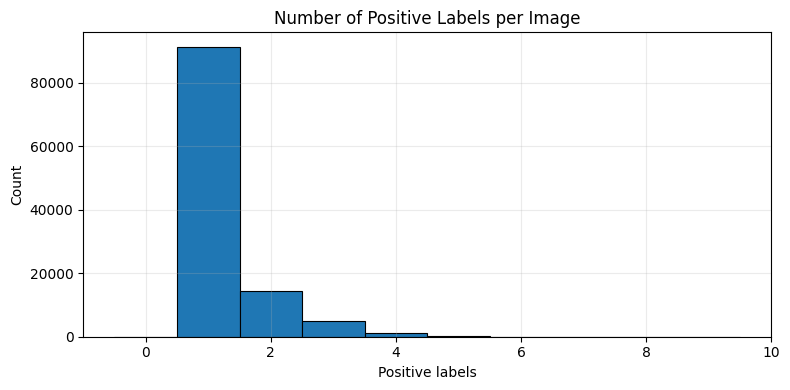

In [4]:
summary = {
    "num_rows_after_filepath_filter": int(len(eda_df)),
    "num_unique_images": int(eda_df["Image Index"].nunique()),
    "num_unique_patients": int(eda_df["Patient ID"].nunique()) if "Patient ID" in eda_df.columns else None,
    "avg_labels_per_image": float(eda_df["num_labels"].mean()),
    "median_labels_per_image": float(eda_df["num_labels"].median()),
    "pct_no_finding": float((eda_df["No Finding"] == 1).mean() * 100.0),
}

summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
display(summary_df)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0, eda_df["num_labels"].max() + 2) - 0.5
ax.hist(eda_df["num_labels"], bins=bins, edgecolor="black", linewidth=0.8)
ax.set_title("Number of Positive Labels per Image")
ax.set_xlabel("Positive labels")
ax.set_ylabel("Count")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 2) Class Imbalance and Label Frequency

,count,pct
No Finding,60361,53.84
Infiltration,19894,17.74
Effusion,13317,11.88
Atelectasis,11559,10.31
Nodule,6331,5.65
Mass,5782,5.16
Pneumothorax,5302,4.73
Consolidation,4667,4.16
Pleural_Thickening,3385,3.02
Cardiomegaly,2776,2.48


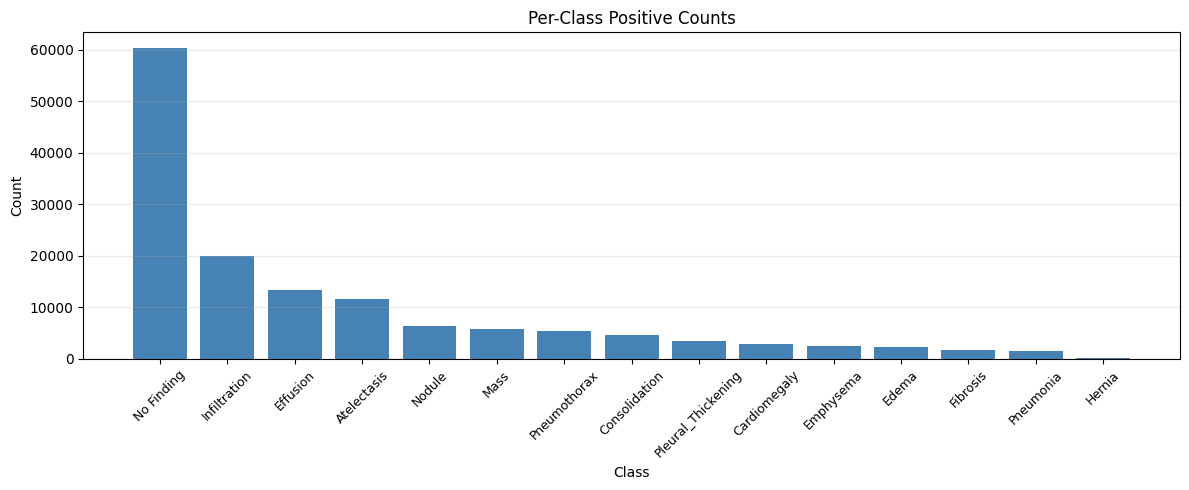

Imbalance ratio (max/min non-zero class count): 265.91x


In [5]:
class_counts = eda_df[config.CLASS_NAMES].sum(axis=0).sort_values(ascending=False)
class_pct = (class_counts / len(eda_df) * 100.0).round(2)
class_stats = pd.DataFrame({"count": class_counts.astype(int), "pct": class_pct})
display(class_stats)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(class_stats.index, class_stats["count"], color="steelblue")
ax.set_title("Per-Class Positive Counts")
ax.set_ylabel("Count")
ax.set_xlabel("Class")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts[class_counts > 0].min()
print(f"Imbalance ratio (max/min non-zero class count): {imbalance_ratio:.2f}x")

## 3) Label Co-occurrence Matrix

Each cell is normalized by the row class support and represents:

$$P(\text{class } j \mid \text{class } i)$$

Interpretation: for X-rays that have class $i$, the cell value shows the fraction that also have class $j$.

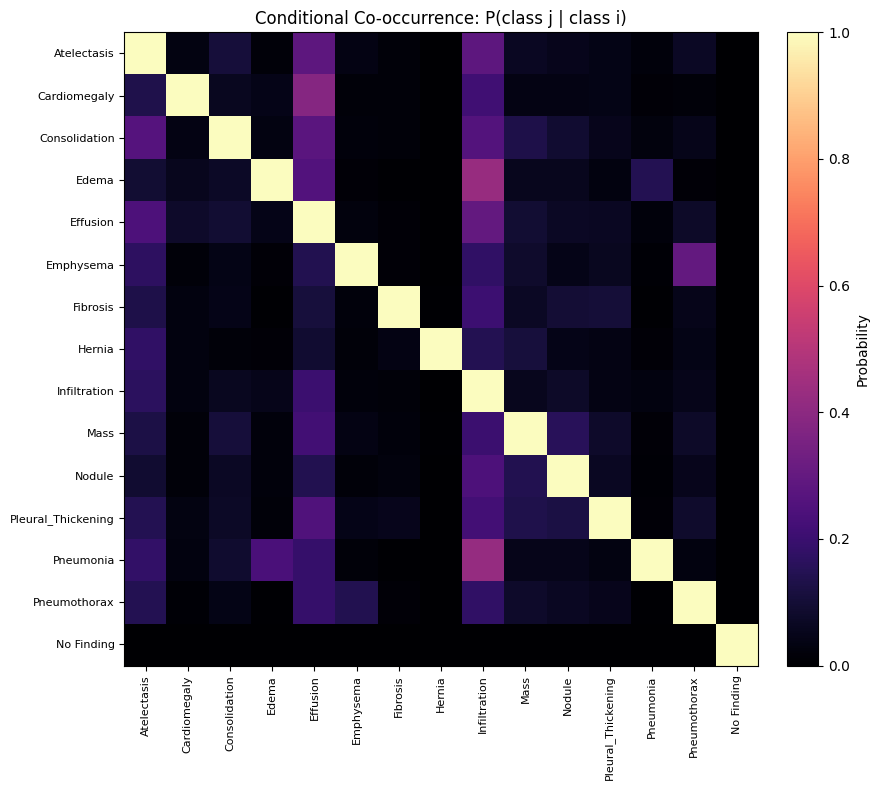

In [6]:
Y = eda_df[config.CLASS_NAMES].to_numpy(dtype=np.float32)
co_counts = Y.T @ Y
support = Y.sum(axis=0)
support_safe = np.where(support == 0, 1.0, support)
cond = co_counts / support_safe[:, None]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cond, cmap="magma", vmin=0.0, vmax=1.0)
ax.set_xticks(np.arange(len(config.CLASS_NAMES)))
ax.set_yticks(np.arange(len(config.CLASS_NAMES)))
ax.set_xticklabels(config.CLASS_NAMES, rotation=90, fontsize=8)
ax.set_yticklabels(config.CLASS_NAMES, fontsize=8)
ax.set_title("Conditional Co-occurrence: P(class j | class i)")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Probability")
plt.tight_layout()
plt.show()

## 4) Official Split Integrity and Leakage Checks

This validates the same split files used in training (`train_val_list.txt` and `test_list.txt`).

In [7]:
train_val_names = set(TRAIN_VAL_LIST.read_text().strip().splitlines())
test_names = set(TEST_LIST.read_text().strip().splitlines())

split_overlap = train_val_names.intersection(test_names)
print(f"train_val size (list): {len(train_val_names):,}")
print(f"test size (list):      {len(test_names):,}")
print(f"filename overlap:      {len(split_overlap):,}")

train_val_df = eda_df[eda_df["Image Index"].isin(train_val_names)].copy()
test_df = eda_df[eda_df["Image Index"].isin(test_names)].copy()

print(f"usable train_val rows: {len(train_val_df):,}")
print(f"usable test rows:      {len(test_df):,}")

if "Patient ID" in eda_df.columns:
    train_patients = set(train_val_df["Patient ID"].unique())
    test_patients = set(test_df["Patient ID"].unique())
    patient_overlap = train_patients.intersection(test_patients)
    print(f"patient overlap across train_val/test: {len(patient_overlap):,}")
else:
    print("Column 'Patient ID' missing: patient leakage check skipped")

train_val size (list): 86,524
test size (list):      25,596
filename overlap:      0
usable train_val rows: 86,524
usable test rows:      25,596
patient overlap across train_val/test: 0


## 5) Image Dimension and Pixel Intensity Profile

To keep runtime practical, dimensions and intensity statistics are sampled by default.

Dimension summary (sampled):


,count,mean,std,min,25%,50%,75%,max
width,5000.0,1024.0,0.0,1024.0,1024.0,1024.0,1024.0,1024.0
height,5000.0,1024.0,0.0,1024.0,1024.0,1024.0,1024.0,1024.0


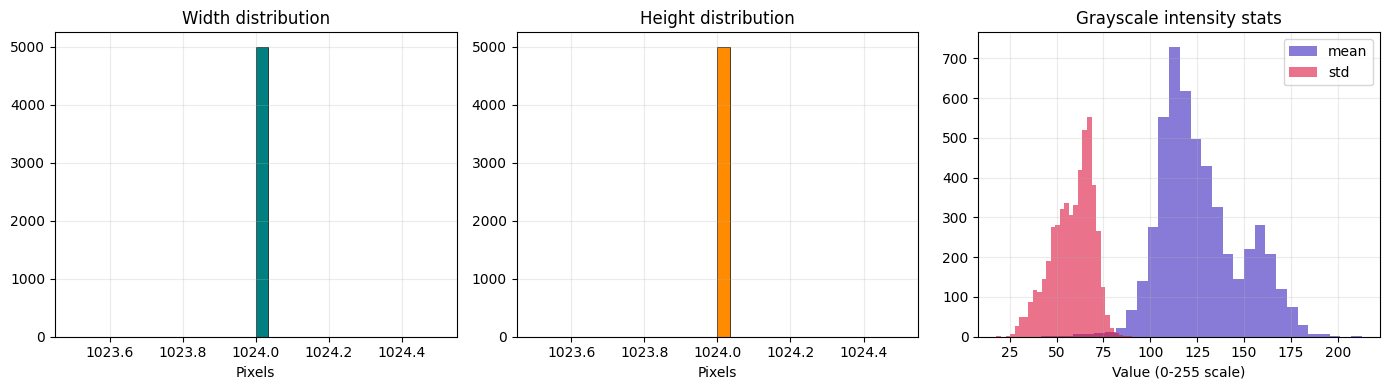

In [8]:
SAMPLE_N = min(5000, len(eda_df))
sample_idx = RNG.choice(len(eda_df), size=SAMPLE_N, replace=False)
sample_paths = eda_df.iloc[sample_idx]["filepath"].tolist()

dims = []
intensity_means = []
intensity_stds = []

for p in sample_paths:
    arr = np.asarray(Image.open(p).convert("L"), dtype=np.float32)
    h, w = arr.shape
    dims.append((w, h))
    intensity_means.append(arr.mean())
    intensity_stds.append(arr.std())

dim_df = pd.DataFrame(dims, columns=["width", "height"])

print("Dimension summary (sampled):")
display(dim_df.describe().T)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(dim_df["width"], bins=30, color="teal", edgecolor="black", linewidth=0.5)
axes[0].set_title("Width distribution")
axes[0].set_xlabel("Pixels")
axes[0].grid(alpha=0.25)

axes[1].hist(dim_df["height"], bins=30, color="darkorange", edgecolor="black", linewidth=0.5)
axes[1].set_title("Height distribution")
axes[1].set_xlabel("Pixels")
axes[1].grid(alpha=0.25)

axes[2].hist(intensity_means, bins=30, alpha=0.8, label="mean", color="slateblue")
axes[2].hist(intensity_stds, bins=30, alpha=0.6, label="std", color="crimson")
axes[2].set_title("Grayscale intensity stats")
axes[2].set_xlabel("Value (0-255 scale)")
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 6) Visual Sanity Check: Random Sample Grid

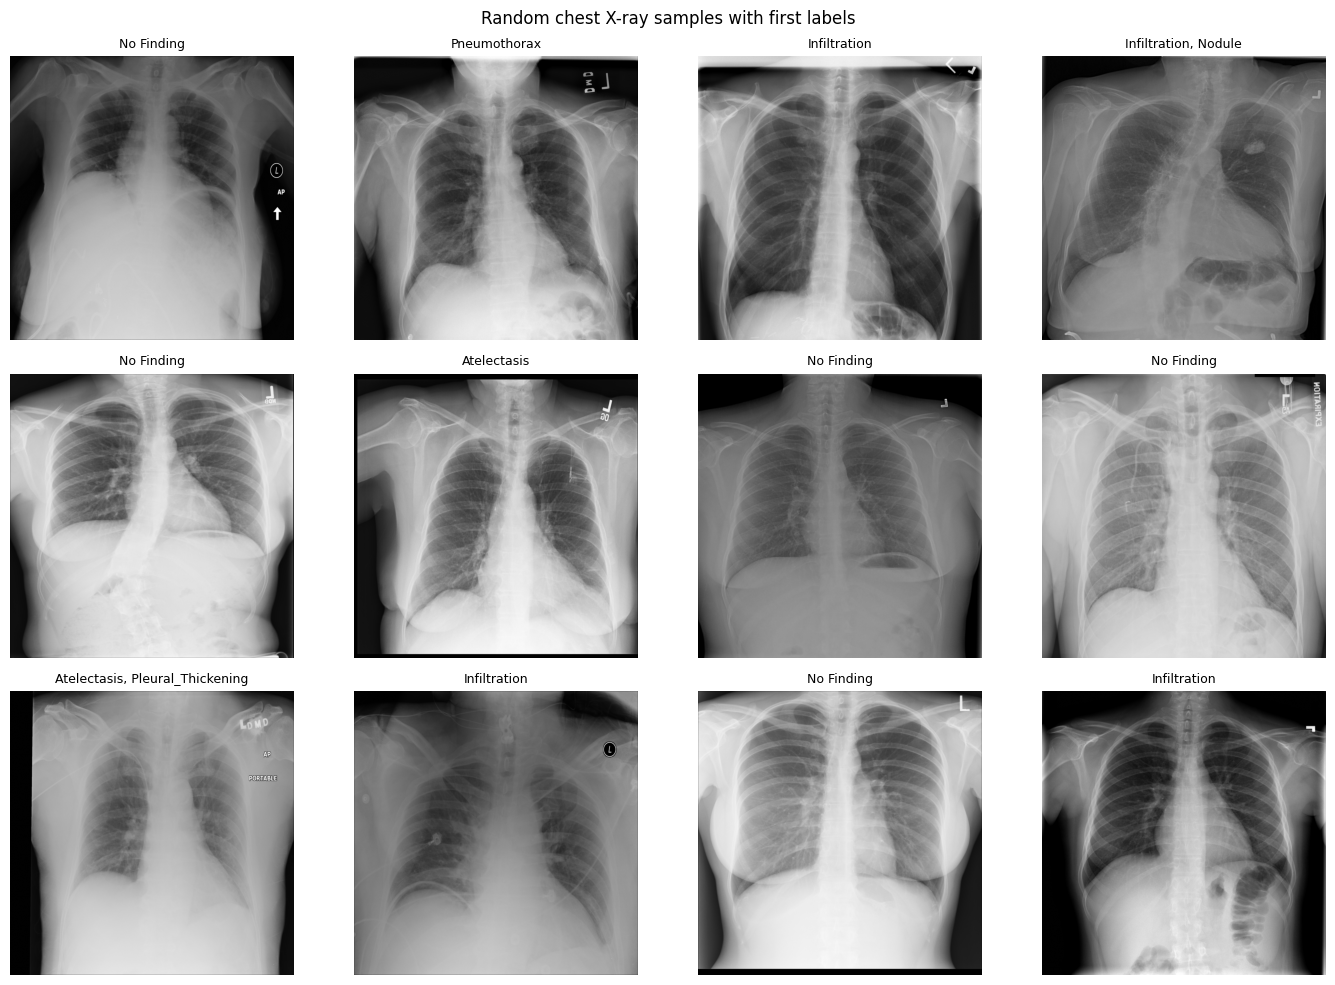

In [9]:
N_SHOW = 12
show_idx = RNG.choice(len(eda_df), size=N_SHOW, replace=False)
show_df = eda_df.iloc[show_idx]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.ravel()

for ax, (_, row) in zip(axes, show_df.iterrows()):
    img = Image.open(row["filepath"]).convert("L")
    ax.imshow(img, cmap="gray")
    labels = [c for c in config.CLASS_NAMES if row[c] == 1]
    label_text = ", ".join(labels[:2]) + ("..." if len(labels) > 2 else "")
    ax.set_title(label_text if label_text else "(no labels)", fontsize=9)
    ax.axis("off")

plt.suptitle("Random chest X-ray samples with first labels", y=0.98)
plt.tight_layout()
plt.show()

## 7) Save EDA Artifacts

This writes summary tables to disk so EDA results remain versionable and reproducible.

In [10]:
summary_df.to_csv(EDA_OUT / "summary_metrics.csv")
class_stats.to_csv(EDA_OUT / "class_distribution.csv")

# Save co-occurrence matrix as CSV
co_df = pd.DataFrame(cond, index=config.CLASS_NAMES, columns=config.CLASS_NAMES)
co_df.to_csv(EDA_OUT / "label_conditional_cooccurrence.csv")

# Save a compact split report
split_report = {
    "train_val_names": len(train_val_names),
    "test_names": len(test_names),
    "filename_overlap": len(split_overlap),
    "usable_train_val_rows": len(train_val_df),
    "usable_test_rows": len(test_df),
}
if "Patient ID" in eda_df.columns:
    split_report["patient_overlap"] = int(len(patient_overlap))

pd.DataFrame([split_report]).to_csv(EDA_OUT / "split_integrity_report.csv", index=False)

print("Saved files:")
for p in sorted(EDA_OUT.glob("*.csv")):
    print(" -", p.name)

Saved files:
 - class_distribution.csv
 - label_conditional_cooccurrence.csv
 - split_integrity_report.csv
 - summary_metrics.csv


## Conclusion

This EDA confirms that the dataset and split setup are generally reliable and usable for training, with clear class imbalance that should guide modeling decisions.

1. **Rare classes needing extra care**: Hernia (0.20%), Pneumonia (1.28%), and Fibrosis (1.50%) are extremely rare; Edema, Emphysema, and Cardiomegaly are also relatively rare. These classes are strong candidates for class weighting and per-class threshold tuning.
2. **Leakage checks**: Train/test filename overlap is zero and patient overlap is zero, which is the expected outcome for clean split integrity.
3. **Image size consistency**: Sampled images are consistently 1024x1024, so there is no evidence of width/height variability requiring stronger resize/crop safeguards.
4. **Important co-occurrence patterns**: Strong conditional relationships include Edema -> Infiltration, Pneumonia -> Infiltration, Cardiomegaly -> Effusion, and Emphysema -> Pneumothorax. These dependencies should be considered when interpreting per-class errors and setting class-specific thresholds.

Overall, the main risk factor is label imbalance rather than split leakage or geometric inconsistency, so the most impactful next improvements are imbalance-aware training and calibrated per-class decision thresholds.